# RGB Color model

## Exercise 1) Download and Read the image file named ’baboon.png’ from Mycourse.

In [1]:
import matplotlib . pyplot as plt
from skimage import io
img = io. imread ('baboon.png')

In [2]:
type(img)

numpy.ndarray

In [3]:
img.shape

(500, 500, 4)

In [4]:
img.dtype

dtype('uint8')

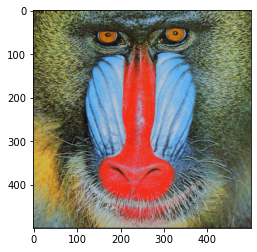

In [5]:
plt.imshow(img)

read image from "baboon.png" to ndarray

## Exercise 2) Next, try the following code to display data of the image

In [6]:
print (img [0])
print (img [0 ,0])
print (img [0 ,0 ,0])

[[133 112  53 255]
 [ 57  53  30 255]
 [ 48  32  24 255]
 ...
 [116 105  62 255]
 [137 150  82 255]
 [170 182 101 255]]
[133 112  53 255]
133


indexing array
x, y, color channel

## Exercise 3) Try the following command to display the image

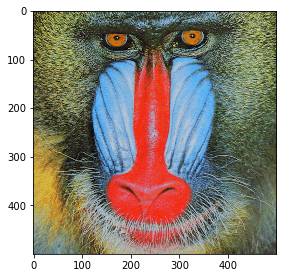

In [7]:
plt. figure ( figsize =(4 , 4) )
plt. imshow (img , cmap ='gray', interpolation ='nearest')
plt. axis ('on')
plt. tight_layout ()
plt. show ()

use plt to show the image baboon

## Exercise 4) After understood the basic concepts of the image, let’s see details of a given image using the following commands

In [8]:
print (img. dtype )
print (img. shape )
print (img. size )
print ( type (img) )

uint8
(500, 500, 4)
1000000
<class 'numpy.ndarray'>


from data above, this image is 500 by 500 RGBA, represent with uint8 ndarray 

## Exercise 5) The next step is to display the following data from the image

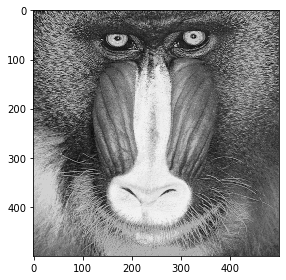

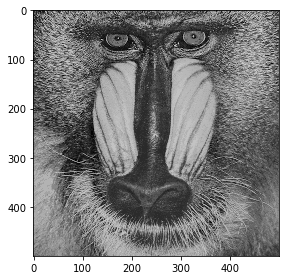

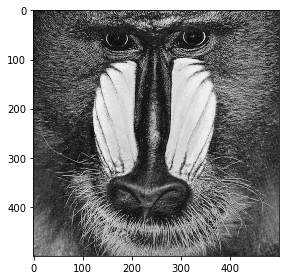

In [9]:
io. imshow ( img [: ,: ,0])
io. show ()
io. imshow ( img [: ,: ,1])
io. show ()
io. imshow ( img [: ,: ,2])
io. show ()

3 images above represent intensity of each color RGB

## Exercise 6) Let’s change the way to display the image

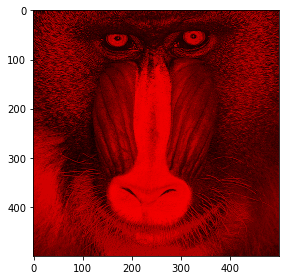

In [10]:
red_image = img. copy ()
red_image [: ,: ,1] = 0
red_image [: ,: ,2] = 0
io. imshow ( red_image )
io. show ()

- red_image [: ,: ,1] = 0
- red_image [: ,: ,2] = 0

these two line set Green and Blue color to zeros

## Exercise 7) Let’s try another example.

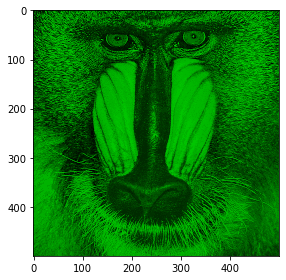

In [14]:
green_image = img. copy ()
green_image [: ,: ,0] = 0
green_image [: ,: ,2] = 0
io. imshow ( green_image )
io. show ()

- green_image [: ,: ,0] = 0
- green_image [: ,: ,2] = 0

these two line set Red and Blue color to zeros

## Exercise 8) Let’s try to display the image in BLUE by yourself.

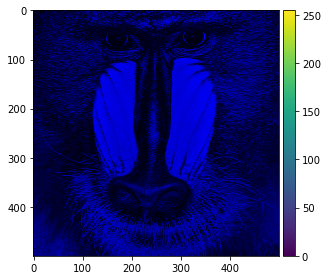

In [13]:
blue_image = img. copy ()
blue_image [: ,: ,0] = 0
blue_image [: ,: ,1] = 0
io. imshow (blue_image)
io. show ()

# Image Manipulation

## Exercise 9) Display the image using the following commands

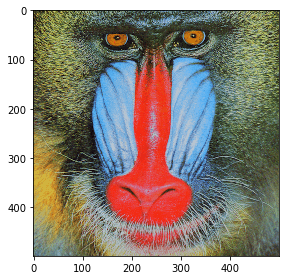

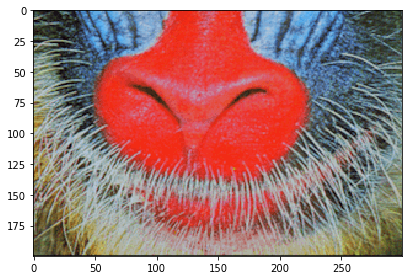

In [15]:
io. imshow ( img [1:500 ,1:500])
io. show ()
io. imshow ( img [300:500 ,100:400])
io. show ()

cropping image

## Exercise 10) Try to crop the given image and display as example below.

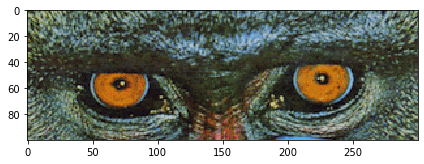

In [18]:
io.imshow(img[0:100, 100:400])

## Exercise 11) Try the following code to see example of masking an image

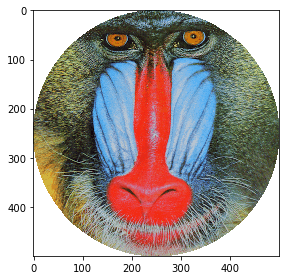

In [19]:
import numpy as np
test_image = img. copy ()
lx , ly , lz = test_image . shape
X, Y = np. ogrid [0:lx , 0: ly]
mask = (X - lx / 2) ** 2 + (Y - ly / 2) ** 2 > lx * ly / 4;
test_image [ mask ]=0;
io. imshow ( test_image )
io. show ()


create a mask that satisfied $(x - \frac{len_x}{2})^2 + (y - \frac{len_y}{2})^2 > \frac{len_x * len_y }{4}$

above equation satisfied when "in" of circle where centre at $(len_x, len_y)$ with radius is $\frac{len_x*len_y}{4}$

if we filp inequality sign, then we will get "out" of circle

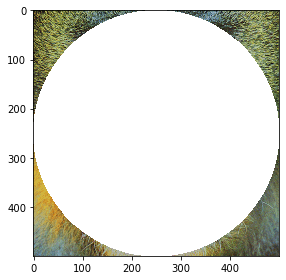

In [21]:
test_image1 = img. copy ()
lx , ly , lz = test_image1 . shape
X, Y = np. ogrid [0:lx , 0: ly]
mask = (X - lx / 2) ** 2 + (Y - ly / 2) ** 2 <= lx * ly / 4;
test_image1 [ mask ]=0;
io. imshow ( test_image1 )
io. show ()

## Exercise 12) If the value of pixel color is go beyond 255, what will happen? Let’s try the following code to see the result.

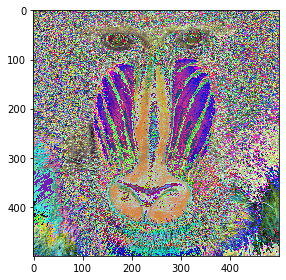

In [22]:
camera_multiply = img *3
io. imshow ( camera_multiply )
io. show ()

since we use uint8 to represent image, which uint8 has range of [0, 255] only, beyond these the value become invalid

# Image transformation and filtering

## Exercise 13) Try the following code to resize the image.

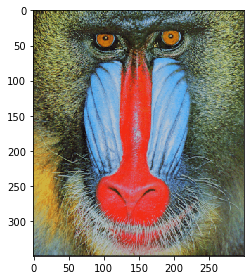

In [24]:
from skimage . transform import resize , rotate , swirl
resized = resize (img , (350 , 300) , mode ='constant', anti_aliasing = True )
io. imshow ( resized )
io. show ()

resized image, as you can see that ratio is not 1:1 anymore

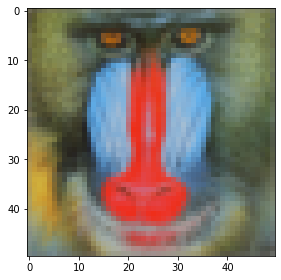

In [25]:
resized = resize (img , (50 , 50) , mode ='constant', anti_aliasing = True )
io. imshow ( resized )
io. show ()

## Exercise 14) Next, try the following command to rotate the image?

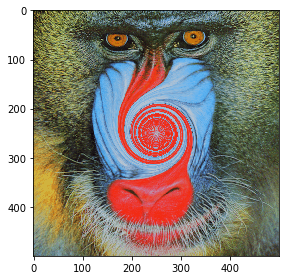

In [26]:
swirled = swirl (img , rotation =0 , strength =100 , radius =120 , mode ='constant')
io. imshow ( swirled )
io. show ()

by transform each pixel using mathematical function. More info https://scikit-image.org/docs/dev/auto_examples/transform/plot_swirl.html

## Exercise 16) Try to blur the image by using the following command

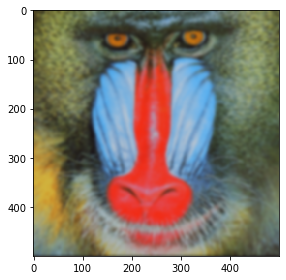

In [29]:
from skimage import filters
blurred_img = filters . gaussian (img , sigma=3 , multichannel=True )
io. imshow ( blurred_img )
io. show ()

amount of blurness can be controled using sigma param

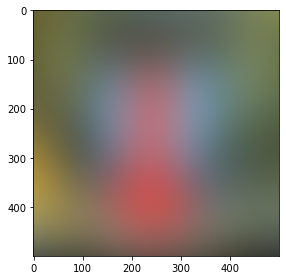

In [30]:
blurred_img = filters . gaussian (img , sigma=50 , multichannel=True )
io. imshow ( blurred_img )
io. show ()

## Exercise 17) Next, Can you try sharpening the image by using the following commands

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


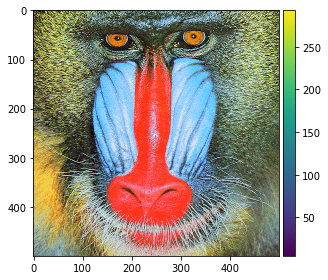

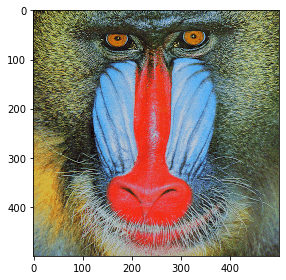

In [36]:
alpha = 0.15
shapened_img = img + alpha * ( img - blurred_img )
io. imshow ( shapened_img . astype ( int) )
io. show ()
io. imshow ( img)
io. show ()

after blur image only the significant parts are left, then subtract that part left out from original image, left with only insignificant part. After scaling with alpha factor, add that insignificant part back to original image.